# Grammar Scoring Engine for Spoken English

**Task:** predict a 0–5 grammar score (MOS, Likert) for 45–60 s spoken English clips.
**Data:** 769 labelled training clips, 216 test clips.
**Metrics:** RMSE (leaderboard metric) and Pearson correlation.

## Report

**Approach in one line:** look at each clip two ways — *what* was said (a Whisper transcript, scored by a fine-tuned text model and interpretable grammar / fluency features) and *how* it was said (frozen WavLM speech embeddings) — blend small, well-validated models on top, and correct for the measured difference between the training and test clips with importance weights, pseudo-labelling and a blend chosen for unseen prompts.

**Why this design.** Grammar is mostly a property of the words, so the pipeline starts with a transcript. But the labels come from human raters who *listened* to the audio, and an ASR system tends to smooth over exactly the hesitations, restarts and broken sentences the rubric describes. A self-supervised speech model sees those directly, which is why the audio branch turned out to be as strong as the text branch. With only ~730 usable labels, large models are either used frozen or fine-tuned briefly with a low learning rate; everything trained on the labels is validated out-of-fold.

**Pipeline**

```
                 ┌─► transcript ─► DeBERTa-v3-base, fine-tuned (5-fold x 10 seeds) ──────────┐
wav ─► Whisper ──┤                ─► RoBERTa-CoLA acceptability, MPNet embedding (20 PCs)    │
  large-v3-turbo └─► word timing  ─► fluency: rate, pauses, fillers, repetitions, cut-offs ─► LightGBM ─┤
wav ─► librosa  ─► signal stats: speech ratio, pause structure, pitch, energy ─────────────┘        ├─► NNLS blend ─► linear
wav ─► WavLM-large (frozen, layer 21, mean+std pooled) ─► Ridge ──────────────────────────────────┘     calibration ─► [0, 5]

importance weights p(test|x) / p(train|x) from adversarial validation are used in every fit, the blend and the calibration;
the final refit also includes the test clips, pseudo-labelled with the first-pass predictions (weight 0.5);
the blend weights are chosen on topic-grouped CV (whole prompts held out), because half the test set is on new prompts
```

**Preprocessing**
- Audio resampled to 16 kHz mono.
- The 37 training clips labelled 0 are non-speech noise (section 2). No test clip has that profile, so they are dropped from training.
- Whisper is pushed towards verbatim output (filler-heavy initial prompt, no conditioning on previous text) so grammatical errors are kept rather than corrected.
- Train and test reuse file names (`train/audio_192.wav` and `test/audio_192.wav` are different recordings — verified by hash), so the two sets are never joined on file name.

**Evaluation**
Stratified 5-fold CV (repeated 3 times for the classic models, 10 seeds for DeBERTa). Every score below is out-of-fold unless marked as training. Because the test set is shifted (section 6), CV is also reported *test-weighted* (each training clip weighted by how test-like it is), which tracked the public leaderboard better than plain CV once the shift mattered (section 12).

**Note on compute.** Transcription, feature extraction and DeBERTa fine-tuning run as scripts in `src/` (logs per clip / fold / epoch in `logs/`); this notebook loads their cached outputs and runs all the modelling, evaluation and plots end to end.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import nnls
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import train as T

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
DATA, FEAT, CACHE = ROOT / "data", ROOT / "artifacts" / "features", ROOT / "artifacts" / "cache"

## 1. Data overview

train: 769 clips | test: 216 clips
file names present in both train/ and test/: 212 (different recordings)


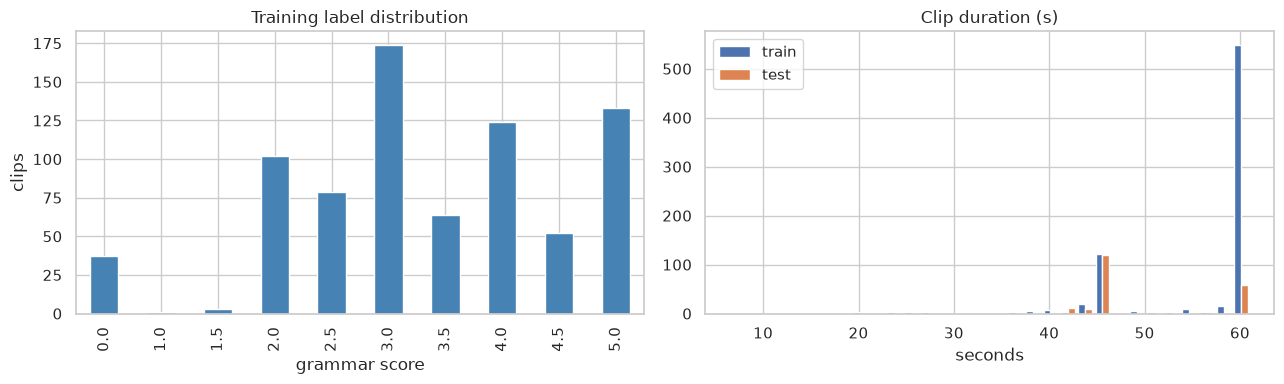

In [2]:
train_all = pd.read_csv(DATA / "train.csv")
test = pd.read_csv(DATA / "test.csv")
audio_tr = pd.read_parquet(FEAT / "train_audio.parquet").loc[train_all.filename]
audio_te = pd.read_parquet(FEAT / "test_audio.parquet").loc[test.filename]
print(f"train: {len(train_all)} clips | test: {len(test)} clips")
print("file names present in both train/ and test/:", len(set(train_all.filename) & set(test.filename)), "(different recordings)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
train_all.label.value_counts().sort_index().plot.bar(ax=ax[0], color="steelblue")
ax[0].set(title="Training label distribution", xlabel="grammar score", ylabel="clips")
ax[1].hist([audio_tr.duration, audio_te.duration], bins=30, label=["train", "test"])
ax[1].set(title="Clip duration (s)", xlabel="seconds"); ax[1].legend()
plt.tight_layout(); plt.show()

Scores are on a half-point scale and concentrated between 2 and 5 (peak at 3). Scores 1.0 and 1.5 have only 4 clips between them, and there is a separate spike of 37 clips at exactly 0.

## 2. The zero-score clips are not speech

,label = 0,label > 0
n_speech_chunks,1.000,69.000
speech_ratio_sig,1.000,0.649
voiced_frac,0.050,0.535
zcr_mean,0.453,0.140
f0_mean,73.940,161.141
gap_mean,0.000,0.235


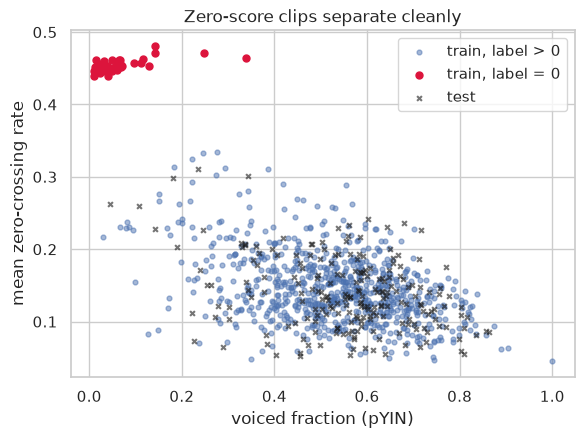

train clips matching the noise profile: 37 | of which label 0: 37
test clips matching the noise profile: 0


In [3]:
is_zero = train_all.label.values == 0
cols = ["n_speech_chunks", "speech_ratio_sig", "voiced_frac", "zcr_mean", "f0_mean", "gap_mean"]
display(pd.DataFrame({"label = 0": audio_tr[is_zero][cols].median(),
                      "label > 0": audio_tr[~is_zero][cols].median()}).round(3))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.scatter(audio_tr.voiced_frac[~is_zero], audio_tr.zcr_mean[~is_zero], s=12, alpha=.5, label="train, label > 0")
ax.scatter(audio_tr.voiced_frac[is_zero], audio_tr.zcr_mean[is_zero], s=25, c="crimson", label="train, label = 0")
ax.scatter(audio_te.voiced_frac, audio_te.zcr_mean, s=12, marker="x", c="k", alpha=.6, label="test")
ax.set(xlabel="voiced fraction (pYIN)", ylabel="mean zero-crossing rate", title="Zero-score clips separate cleanly")
ax.legend(); plt.show()

noise_rule = lambda d: (d.voiced_frac < 0.35) & (d.zcr_mean > 0.3) & (d.n_speech_chunks <= 2)
print("train clips matching the noise profile:", int(noise_rule(audio_tr).sum()), "| of which label 0:", int(noise_rule(audio_tr)[is_zero].sum()))
print("test clips matching the noise profile:", int(noise_rule(audio_te).sum()))

Every zero-score clip is one unbroken block of sound with almost no voiced frames and a very high zero-crossing rate — noise, not a speaker. No test clip has this profile. Keeping these rows would teach the models that a chunk of the label mass sits at 0 for reasons unrelated to grammar, so they are dropped from training.

## 3. Transcription

In [4]:
def read_jsonl(p):
    return {r["filename"]: r for r in map(json.loads, open(p))}

tr_tx = read_jsonl(ROOT / "artifacts/transcripts/train.jsonl")
y, test_idx = T.load_labels()
for score in [2.0, 3.0, 4.0, 5.0]:
    f = y[y == score].index[0]
    print(f"[{score}] {f}\n{tr_tx[f]['text'][:400]}...\n")

[2.0] audio_126.wav
Once upon a time, we, with five friends, went on a tour, went on a tour with a driver agent on a Manali, and we stayed at a resort, and we stayed around, we stayed at a resort, and after that, we stayed, when we checked in in the resort, after that, at night, we played with Yuno, Yuno, we played, and after that, we went on the tour. floor top to see the night view of the city Manali and to enjoy t...

[3.0] audio_192.wav
Well, this, the playground is very, very beautiful and fun. There are, there are playtons like the merry-go-round, the swing. The students usually enjoy the swing. It has to be like, um, it's more like a game of care. because one sits on it and the other takes on it will have to finish. Then the merry-go-round, they just climb on it. Most of them play football in some parks, while others just swin...

[4.0] audio_672.wav
The school playground is very big and is very colorful. It has a lot of games for kids and these games are suitable no matter your

Restarts ("this, the …"), repeated words and fillers survive in the transcripts, which is what the verbatim-biased decoding is for. Lower-scored speakers visibly produce shorter, broken sentences and agreement / tense errors.

## 4. Interpretable features and how they relate to the score

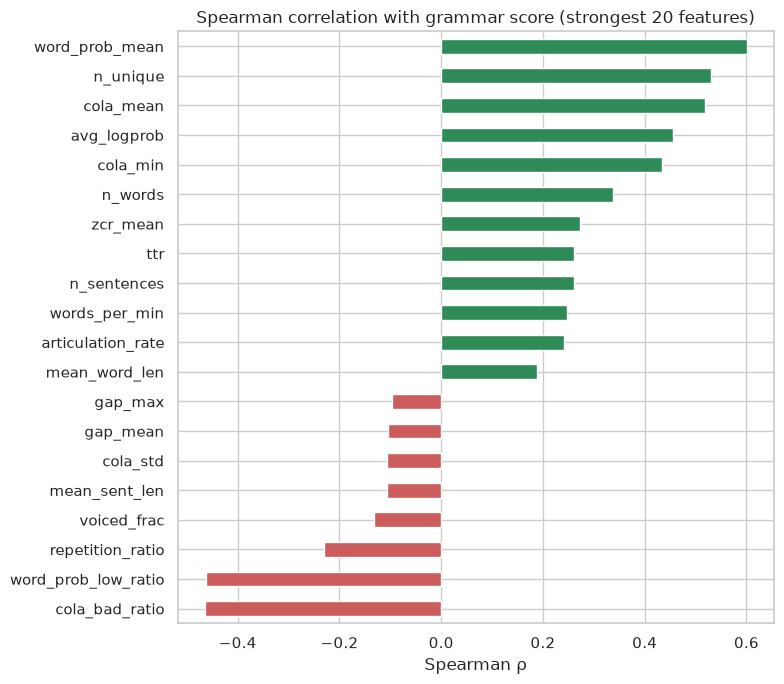

In [5]:
hc = T.load_features("train", ["handcrafted", "grammar", "audio"], y.index)
corr = hc.apply(lambda c: spearmanr(c, y)[0]).dropna().sort_values()
top = pd.concat([corr.head(8), corr.tail(12)])
fig, ax = plt.subplots(figsize=(8, 7))
top.plot.barh(ax=ax, color=np.where(top > 0, "seagreen", "indianred"))
ax.set(title="Spearman correlation with grammar score (strongest 20 features)", xlabel="Spearman ρ")
plt.tight_layout(); plt.show()

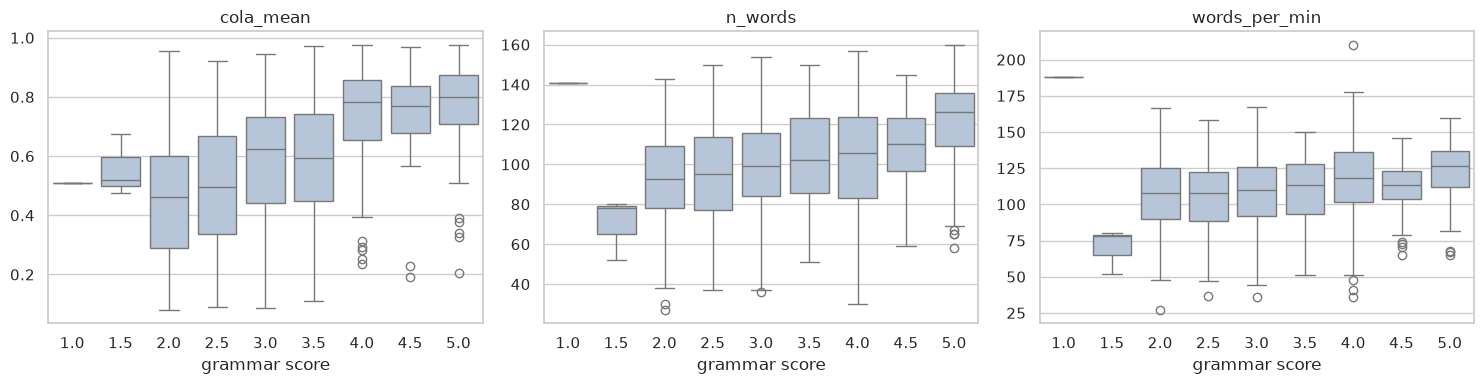

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, c in zip(ax, ["cola_mean", "n_words", "words_per_min"]):
    sns.boxplot(x=y.values, y=hc[c].values, ax=a, color="lightsteelblue")
    a.set(title=c, xlabel="grammar score")
plt.tight_layout(); plt.show()

## 5. Speech embeddings: which WavLM layer?

WavLM is used frozen. For every layer, frame-level hidden states are pooled over the clip (mean + std), and a Ridge model is cross-validated on each layer separately. Lower layers encode acoustics, upper-middle layers more phonetic / word-level information.

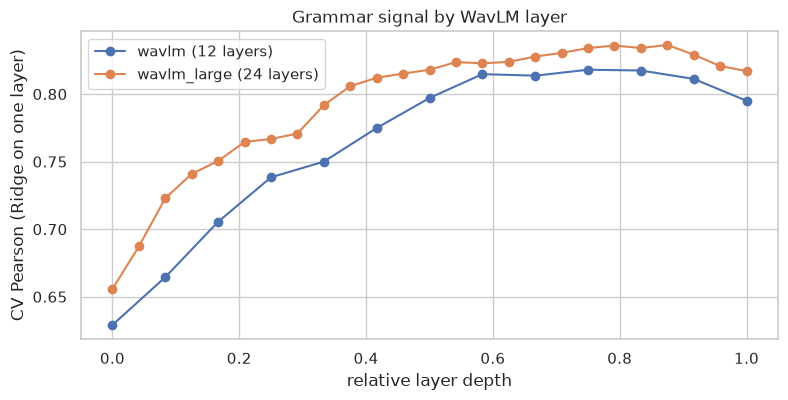

,model,layer,CV RMSE,CV Pearson
9,wavlm,9,0.5896,0.8180
34,wavlm_large,21,0.5596,0.8363


In [7]:
names = train_all.filename.tolist()
pos = [names.index(f) for f in y.index]
ridge_big = lambda: make_pipeline(StandardScaler(), Ridge(alpha=3000.0))
layer_rows = []
for name in ["wavlm", "wavlm_large"]:
    arr = np.load(CACHE / f"train_{name}_layers.npy")[pos]
    for L in range(arr.shape[1]):
        o, _ = T.cross_validate(ridge_big, arr[:, L], y, repeats=1)
        layer_rows.append({"model": name, "layer": L, "CV RMSE": T.rmse(y, o), "CV Pearson": pearsonr(y, o)[0]})
layers = pd.DataFrame(layer_rows)

fig, ax = plt.subplots(figsize=(9, 4))
for name, g in layers.groupby("model"):
    ax.plot(g.layer / g.layer.max(), g["CV Pearson"], marker="o", label=f"{name} ({g.layer.max()} layers)")
ax.set(xlabel="relative layer depth", ylabel="CV Pearson (Ridge on one layer)", title="Grammar signal by WavLM layer")
ax.legend(); plt.show()
layers.loc[layers.groupby("model")["CV RMSE"].idxmin()].round(4)

Signal rises with depth and peaks in the upper-middle layers (base: layer 9 of 12, large: layer 21 of 24) before dropping at the top, which is specialised for the self-supervised pre-training objective. The chosen layer is the one with the lowest CV RMSE.

## 6. Train / test shift (adversarial validation)

From v7 onwards, two changes that improved CV made the public leaderboard *worse*. To check whether the test set differs from the training set, a classifier is trained to tell training clips from test clips: an AUC of 0.5 means the two are indistinguishable.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

def adv_auc(group, n_pca=None):
    tr = T.load_features("train", [group], y.index).values
    te = T.load_features("test", [group], test_idx).values
    X, lab = np.vstack([tr, te]), np.r_[np.zeros(len(tr)), np.ones(len(te))]
    steps = [StandardScaler()] + ([PCA(n_pca, random_state=0)] if n_pca else []) + [LogisticRegression(C=0.1, max_iter=2000)]
    p = cross_val_predict(make_pipeline(*steps), X, lab, cv=StratifiedKFold(5, shuffle=True, random_state=0), method="predict_proba")[:, 1]
    return roc_auc_score(lab, p)

adv = pd.Series({g: adv_auc(g, k) for g, k in [("grammar", None), ("handcrafted", None), ("audio", None),
                                                 ("embedding", 50), ("wavlm", 50), ("wavlm_large", 50)]}, name="train-vs-test AUC")
display(adv.round(3).to_frame())

hc_te = pd.read_parquet(FEAT / "test_handcrafted.parquet")
shift_tbl = pd.DataFrame({
    "train": [audio_tr.loc[y.index, "duration"].mean(), hc.loc[y.index, "words_per_min"].mean(), hc.loc[y.index, "pause_long_count"].mean()],
    "test": [audio_te["duration"].mean(), hc_te["words_per_min"].mean(), hc_te["pause_long_count"].mean()]},
    index=["clip duration (s)", "words per minute", "long pauses per clip"]).round(2)
display(shift_tbl)

,train-vs-test AUC
grammar,0.495
handcrafted,0.720
audio,0.728
embedding,0.777
wavlm,0.807
wavlm_large,0.805


,train,test
clip duration (s),55.68,48.76
words per minute,112.09,123.21
long pauses per clip,3.48,2.61


Grammatical acceptability is not shifted (AUC 0.50), but everything else is: test clips are about 7 s shorter, speakers are faster with fewer long pauses, the topics differ (prompts such as "describe your school playground" are much rarer in the test set), and the speech embeddings are the most shifted of all (AUC about 0.81). Models that fit the training recordings more tightly therefore transfer worse.

**Correction: importance weighting.** The same classifier, trained on all feature groups (AUC 0.83), gives each training clip a weight w = p(test | x) / p(train | x) (out-of-fold, clipped to [0.2, 5], normalised to mean 1). Every model, the blend and the calibration are fitted with these weights, so the solution concentrates on the training clips that look like the test set.

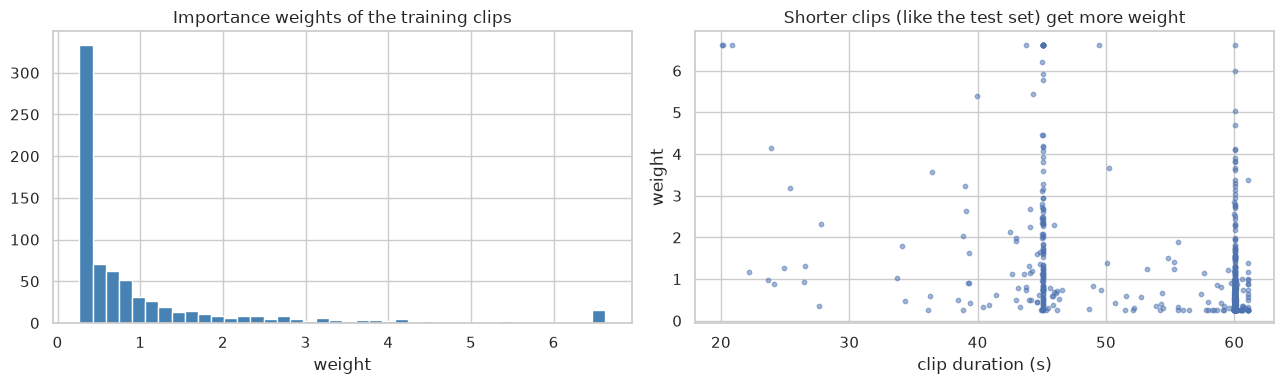

effective sample size: 278 of 732


In [9]:
iw = pd.read_parquet(FEAT / "train_shift_weight.parquet").loc[y.index, "weight"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(iw, bins=40, color="steelblue"); ax[0].set(title="Importance weights of the training clips", xlabel="weight")
ax[1].scatter(audio_tr.loc[y.index, "duration"], iw, s=10, alpha=.5)
ax[1].set(xlabel="clip duration (s)", ylabel="weight", title="Shorter clips (like the test set) get more weight")
plt.tight_layout(); plt.show()
print(f"effective sample size: {iw.sum()**2 / (iw**2).sum():.0f} of {len(iw)}")

## 6b. Topics: the test set is full of new prompts

The clips answer different prompts (a playground, a hobby, a market, an airport, a flood, social media ...). Clustering the transcript embeddings of train + test together (k-means, 8 clusters, no labels involved) recovers them.

In [10]:
ttr = pd.read_parquet(FEAT / "train_topic.parquet").loc[y.index, "topic"]
tte = pd.read_parquet(FEAT / "test_topic.parquet").loc[test_idx, "topic"]
topic_tbl = pd.DataFrame({"train clips": ttr.value_counts(), "test clips": tte.value_counts(),
                          "mean label (train)": y.groupby(ttr.values).mean()}).sort_index().round(2)
display(topic_tbl)
deb_rand = pd.read_parquet(FEAT / "train_deberta.parquet").loc[y.index, "deberta"]
deb_topic = pd.read_parquet(FEAT / "train_deberta_topic.parquet").loc[y.index, "deberta_topic"]
print(f"DeBERTa CV RMSE, random folds (seen prompts):   {T.rmse(y, deb_rand):.4f}")
print(f"DeBERTa CV RMSE, topic-grouped folds (new ones): {T.rmse(y, deb_topic):.4f}")

,train clips,test clips,mean label (train)
0,34,50,2.72
1,98,21,3.46
2,138,14,3.59
3,100,20,3.59
4,118,11,3.40
5,11,57,2.86
6,132,34,3.52
7,101,9,3.61


DeBERTa CV RMSE, random folds (seen prompts):   0.5654
DeBERTa CV RMSE, topic-grouped folds (new ones): 0.6124


Two clusters hold about half of the test clips (107 of 216) but only 45 training clips, and those prompts score lower on average. When whole prompts are held out, DeBERTa's error rises clearly: plain K-fold, where every fold has seen every prompt, is optimistic for this test set. The final blend weights and calibration are therefore chosen on **topic-grouped** OOF predictions (section 13). A per-topic bias correction was also tried and made CV worse: after importance weighting the per-topic biases are close to zero.

## 7. Cross-validated models and the final blend

In [11]:
res = T.run(folds=5, repeats=3)
oof, trp, folds = res["oof"], res["train_pred"], res["folds"]

summary = pd.DataFrame({
    "train RMSE": {m: T.rmse(y, trp[m]) for m in oof},
    "CV RMSE": {m: T.rmse(y, oof[m]) for m in oof},
    "CV Pearson": {m: pearsonr(y, oof[m])[0] for m in oof},
    "blend weight": {**{k: v for k, v in res["weights"].items()}, "blend": 1.0},
}).round(4)
summary

,train RMSE,CV RMSE,CV Pearson,blend weight
ridge,0.5391,0.7031,0.7212,0.0000
svr,0.3354,0.7058,0.7249,0.0000
lgbm,0.3155,0.5618,0.8333,0.2160
ridge_wavlm,0.5248,0.5963,0.8158,0.0823
ridge_wavlm_large,0.4900,0.5739,0.8295,0.2280
deberta,0.1399,0.5654,0.8312,0.4737
blend,0.2283,0.5069,0.8679,1.0000


- **Training RMSE** = error on the clips the model was fitted on (classic models: refit on all training data; DeBERTa: each fold model on its own training clips, averaged). **CV RMSE / Pearson** = out-of-fold, the honest estimate. The gap shows how much each model fits noise.
- The blend weights come from importance-weighted non-negative least squares on the out-of-fold predictions. Ridge / SVR on text features get zero weight: DeBERTa already carries what they offer.

In [12]:
print(f"TRAINING RMSE         (final blend, on training data):   {T.rmse(y, trp['blend']):.4f}")
print(f"CV RMSE               (final blend, out-of-fold):        {T.rmse(y, oof['blend']):.4f}")
print(f"test-weighted CV RMSE (out-of-fold, test-like clips):    {T.wrmse(y, oof['blend'], iw):.4f}")
print(f"CV Pearson            (final blend, out-of-fold):        {pearsonr(y, oof['blend'])[0]:.4f}")

TRAINING RMSE         (final blend, on training data):   0.2283
CV RMSE               (final blend, out-of-fold):        0.5069
test-weighted CV RMSE (out-of-fold, test-like clips):    0.4878
CV Pearson            (final blend, out-of-fold):        0.8679


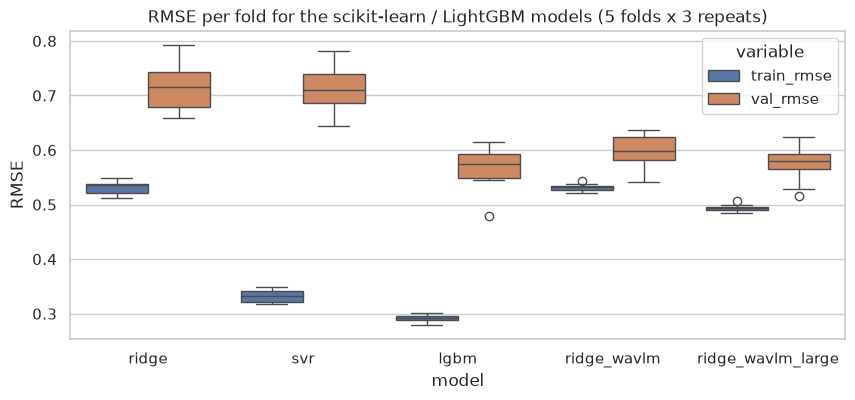

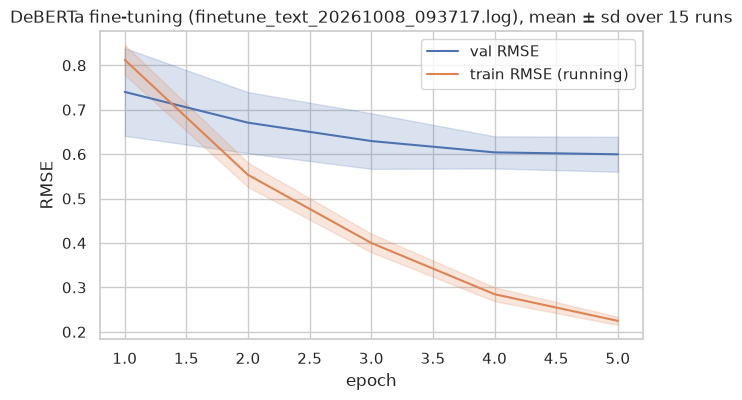

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=folds.melt(id_vars=["model", "fold"], value_vars=["train_rmse", "val_rmse"]),
            x="model", y="value", hue="variable", ax=ax)
ax.set(title="RMSE per fold for the scikit-learn / LightGBM models (5 folds x 3 repeats)", ylabel="RMSE")
plt.show()

# DeBERTa learning curve, read from the fine-tuning log (val RMSE after every epoch, 3 seeds x 5 folds)
import re
log = next(p for p in sorted((ROOT / "logs").glob("finetune_text_*.log"), reverse=True) if "seed avg" in p.read_text())
rows = [dict(zip(["seed", "fold", "epoch", "train_mse", "val_rmse"], map(float, m.groups())))
        for m in re.finditer(r"seed (\d+) fold (\d+) epoch (\d+) \| train MSE ([\d.]+) \| val RMSE ([\d.]+)", log.read_text())]
curve = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 4))
sns.lineplot(data=curve, x="epoch", y="val_rmse", errorbar="sd", ax=ax, label="val RMSE")
sns.lineplot(data=curve.assign(train_rmse=np.sqrt(curve.train_mse)), x="epoch", y="train_rmse", errorbar="sd", ax=ax, label="train RMSE (running)")
ax.set(title=f"DeBERTa fine-tuning ({log.name}), mean ± sd over 15 runs", ylabel="RMSE"); plt.show()

## 8. Predictions vs. ground truth

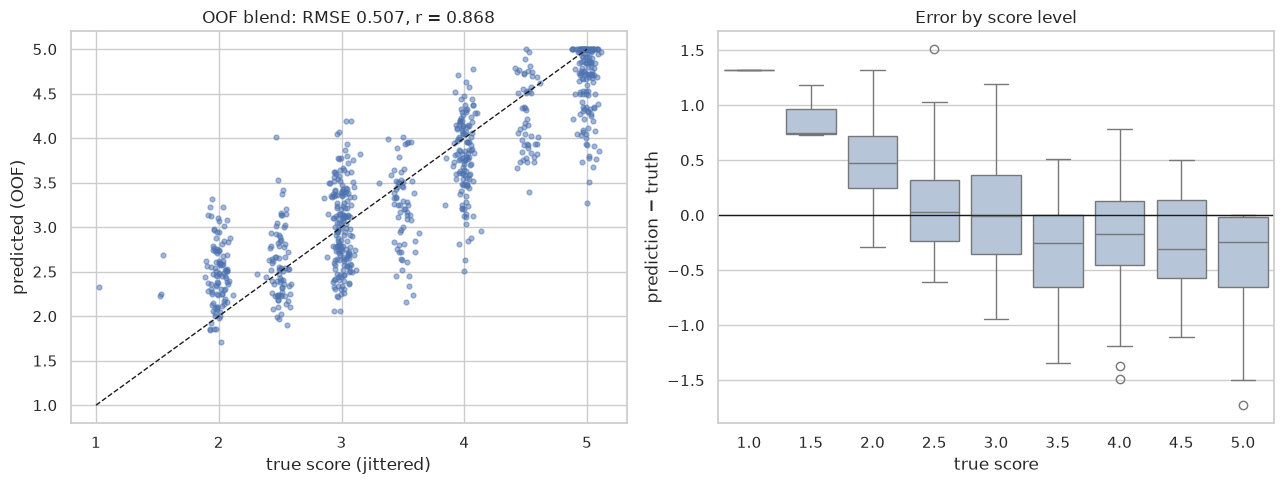

label         1.0    1.5      2.0     2.5      3.0     3.5      4.0     4.5      5.0
n           1.000  3.000  102.000  79.000  174.000  64.000  124.000  52.000  133.000
RMSE        1.324  0.911    0.592   0.402    0.466   0.541    0.481   0.474    0.537
mean error  1.324  0.887    0.480   0.083    0.009  -0.295   -0.195  -0.241   -0.365


In [14]:
p = oof["blend"]
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
jit = np.random.default_rng(0).normal(0, .05, len(y))
ax[0].scatter(y + jit, p, s=12, alpha=.5)
ax[0].plot([1, 5], [1, 5], "k--", lw=1)
ax[0].set(xlabel="true score (jittered)", ylabel="predicted (OOF)",
          title=f"OOF blend: RMSE {T.rmse(y, p):.3f}, r = {pearsonr(y, p)[0]:.3f}")
sns.boxplot(x=y.values, y=(p - y).values, ax=ax[1], color="lightsteelblue")
ax[1].axhline(0, c="k", lw=1)
ax[1].set(xlabel="true score", ylabel="prediction − truth", title="Error by score level")
plt.tight_layout(); plt.show()
print(pd.DataFrame({"n": y.groupby(y).size(), "RMSE": (p - y).pow(2).groupby(y).mean().pow(.5).round(3),
                    "mean error": (p - y).groupby(y).mean().round(3)}).T.to_string())

Errors are smallest in the crowded middle of the scale and grow at the extremes: the rare low scores are over-predicted and some 5s under-predicted. The linear calibration step stretches the blend to undo part of this shrinkage (it costs Pearson nothing and lowers RMSE).

## 9. Ablation

### 9a. Feature groups (single Ridge model, CV)

In [15]:
ridge = lambda: make_pipeline(StandardScaler(), Ridge(alpha=300.0))
setups = {
    "audio signal stats": ["audio"],
    "grammar (CoLA)": ["grammar"],
    "MPNet embedding": ["embedding"],
    "fluency + text stats": ["handcrafted"],
    "handcrafted + grammar + embedding": ["handcrafted", "grammar", "embedding"],
}
rows = []
for name, g in setups.items():
    X = T.load_features("train", g, y.index)
    o, _ = T.cross_validate(ridge, X, y, repeats=1)
    rows.append({"features": name, "n_features": X.shape[1], "CV RMSE": T.rmse(y, o), "CV Pearson": pearsonr(y, o)[0]})
for name in ["wavlm", "wavlm_large"]:
    X = T.load_features("train", [name], y.index)
    o, _ = T.cross_validate(ridge_big, X, y, repeats=1)
    rows.append({"features": f"{name} (best layer)", "n_features": X.shape[1], "CV RMSE": T.rmse(y, o), "CV Pearson": pearsonr(y, o)[0]})
pd.DataFrame(rows).set_index("features").round(4)

,n_features,CV RMSE,CV Pearson
features,,,
audio signal stats,15,0.9485,0.3606
grammar (CoLA),4,0.8824,0.4995
MPNet embedding,768,0.7899,0.6302
fluency + text stats,22,0.7528,0.6809
handcrafted + grammar + embedding,794,0.6935,0.7299
wavlm (best layer),1536,0.5896,0.8180
wavlm_large (best layer),2048,0.5596,0.8363


### 9b. Which models the blend needs (blend refitted on each subset of out-of-fold predictions)

In [16]:
def blend_score(models):
    A = oof[models].values
    w, _ = nnls(A, y.values)
    pred = np.clip(A @ (w / w.sum()), 0, 5)
    return T.rmse(y, pred), pearsonr(y, pred)[0]

subsets = {
    "DeBERTa only (text)": ["deberta"],
    "WavLM-large only (audio)": ["ridge_wavlm_large"],
    "LightGBM only (features)": ["lgbm"],
    "DeBERTa + LightGBM  (v2/v3 style)": ["deberta", "lgbm"],
    "DeBERTa + WavLM-large": ["deberta", "ridge_wavlm_large"],
    "DeBERTa + WavLM-large + LightGBM": ["deberta", "ridge_wavlm_large", "lgbm"],
    "all models": [c for c in oof.columns if c != "blend"],
}
pd.DataFrame({k: dict(zip(["CV RMSE", "CV Pearson"], blend_score(v))) for k, v in subsets.items()}).T.round(4)

,CV RMSE,CV Pearson
DeBERTa only (text),0.5654,0.8312
WavLM-large only (audio),0.5729,0.8315
LightGBM only (features),0.5613,0.8339
DeBERTa + LightGBM (v2/v3 style),0.5230,0.8581
DeBERTa + WavLM-large,0.5162,0.8650
DeBERTa + WavLM-large + LightGBM,0.5111,0.8684
all models,0.5111,0.8687


Text and speech are complementary: either one alone gets to about r = 0.83, together they get to about 0.87. The feature-based LightGBM adds a little on top. (Numbers here are before the final calibration step.)

### 9c. Tried and not kept

In [17]:
res_llm = T.run(folds=5, repeats=3, use_llm=True)
L = T.load_features("train", ["llm"], y.index)
print(f"Qwen3-4B zero-shot rubric score alone:  r = {pearsonr(y, L.llm_expected)[0]:.3f}")
print(f"final blend without LLM features:       CV RMSE {T.rmse(y, oof['blend']):.4f}")
print(f"final blend with LLM features:          CV RMSE {T.rmse(y, res_llm['oof']['blend']):.4f}")

Qwen3-4B zero-shot rubric score alone:  r = 0.582
final blend without LLM features:       CV RMSE 0.5069
final blend with LLM features:          CV RMSE 0.5065


| Idea | Result | Kept? |
|---|---|---|
| Zero-shot LLM judge (Qwen3-4B, 4-bit) reading the rubric, P(score 1–5) as features | r ≈ 0.58 alone; no CV gain once DeBERTa is in (public LB also slightly worse) | no |
| DeBERTa averaged over 3 seeds instead of 1 | CV about the same, steadier test predictions | yes |
| DeBERTa averaged over 10 seeds instead of 3 (Kaggle T4, v23) | DeBERTa CV 0.570 → 0.565 (unseen topics 0.622 → 0.612); public LB 0.3190 → 0.3173 | yes |
| DeBERTa-v3-large | does not fit a 6 GB GPU at a usable speed (spills into system RAM) | not run |
| Ridge / SVR on text features | zero blend weight once DeBERTa is in | in code, weight 0 |
| WavLM-base embeddings | strong alone (r ≈ 0.82) but redundant with WavLM-large | in code, weight 0 |
| RBF-SVR on PCA-128 of the WavLM embeddings (v8, v13a) | better CV, worse public LB both without and with shift weights | no (`--svr_audio`) |
| WavLM-base fine-tuned end to end (v9, v13b) | better CV, worse public LB both without and with shift weights | no (`src/finetune_audio.py`) |
| Stronger importance weights (clip 0.1–10, v11a) | effective sample size drops to ~190; worse | no |
| Per-minute rates instead of counts | worse test-weighted CV | no (`--duration_free`) |
| DeBERTa trained with a weighted loss (v12b) | zero blend weight next to the unweighted DeBERTa; worse when it replaces it | no |
| DeBERTa-v3-large (Kaggle T4) | CV 0.555, small blend weight; public LB tie (0.3203) | no |
| Grammatical-error-correction features (CoEdIT-large edit counts) | correlate -0.46 with the score, but no CV or LB gain: DeBERTa already captures it | no (`--gec`) |
| WavLM-large fine-tuned end to end (Kaggle T4) | CV 0.604, zero blend weight | no |
| Per-topic bias correction | worse CV at every shrinkage level | no |
| Pseudo-labels from the v18 predictions instead of the first pass (v20) | public LB 0.3196 | no |
| Second transcript (Whisper large-v3) + DeBERTa on it (v21) | DeBERTa OOF correlates 0.96 with the turbo one; no CV gain, public LB 0.3193 | no (`kaggle/second_transcript.py`) |
| Ridge on Whisper encoder embeddings (medium / large-v3, last layer; v22) | best single model on unseen topics (0.565) and unseen-topic CV 0.522 → 0.505, but public LB worse (0.3193–0.3235) — the same pattern as every other extra audio model | no (`kaggle/whisper_embed.py`, `--whisper`) |

## 10. Feature importance (LightGBM)

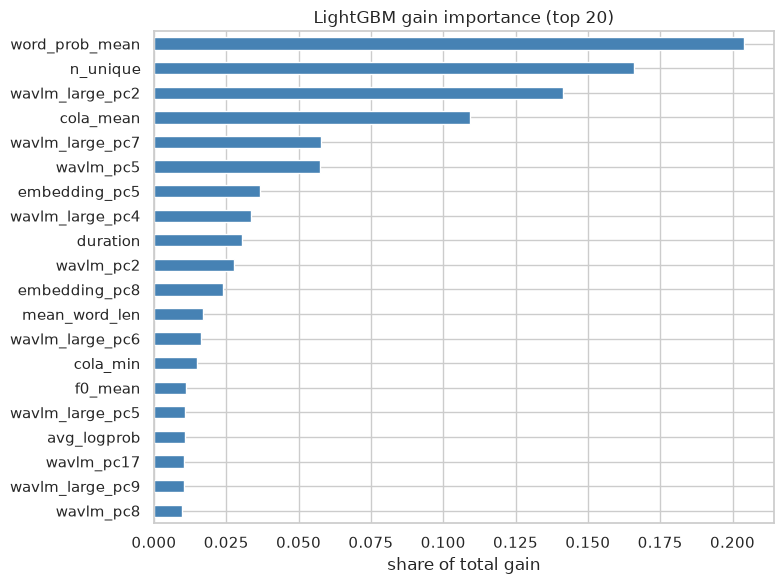

In [18]:
groups, build = T.make_models()["lgbm"]
X = T.load_features("train", groups, y.index)
m = build().set_params(importance_type="gain").fit(X, y)
imp = pd.Series(m.feature_importances_, index=X.columns).sort_values().tail(20)
fig, ax = plt.subplots(figsize=(8, 6))
(imp / imp.sum()).plot.barh(ax=ax, color="steelblue")
ax.set(title="LightGBM gain importance (top 20)", xlabel="share of total gain")
plt.tight_layout(); plt.show()

## 11. Error analysis

In [19]:
err = (oof["blend"] - y).rename("error")
worst = err.abs().sort_values(ascending=False).head(6).index
for f in worst:
    print(f"{f} | true {y[f]} | predicted {oof.loc[f, 'blend']:.2f} | DeBERTa {oof.loc[f, 'deberta']:.2f} | WavLM-large {oof.loc[f, 'ridge_wavlm_large']:.2f}")
    print("   ", tr_tx[f]["text"][:300], "...\n")

audio_159.wav | true 5.0 | predicted 3.27 | DeBERTa 3.38 | WavLM-large 3.48
    Okay, um, immersing in the melodic tranquility of a hidden forest clay, a journey in the nature sanctuary, where sunlight filters through canopy, birdsong fills the air, and time slips into a gentle hush, and also there's a embarking on a enchanted voyage, delving deep into the the verdant mysteries ...

audio_170.wav | true 2.5 | predicted 4.01 | DeBERTa 3.95 | WavLM-large 3.77
    I think the goal that I am achieving right now is to be happy. Completely happy. Because I think in this generation, it's not easy to achieve. And also, just being here, I like to achieve, like, my small means of life, such as having my own space, because it's not easy to live with my parents right  ...

audio_91.wav | true 5.0 | predicted 3.50 | DeBERTa 3.56 | WavLM-large 3.41
    Imagine a vibrant marketplace in Vanilla, bustling with activities. Vendors with colorful stalls are shouting out with their wares. Voicely, lively, 

The largest misses are mostly clips whose transcript reads fluently but which the raters scored low (or the reverse). Likely causes: Whisper smoothing over errors the raters heard, very short answers, and some label noise — the same speaker features that help on average can mislead on individual clips.

## 12. Submission history: CV vs. public leaderboard

| Version | Change | CV RMSE | CV Pearson | Public LB RMSE |
|---|---|---|---|---|
| v1 | Ridge / SVR / LightGBM on frozen features | 0.611 | 0.803 | 0.4251 |
| v2 | + DeBERTa-v3-base fine-tuned on transcripts | 0.538 | 0.848 | 0.3523 |
| v3 | DeBERTa averaged over 3 seeds | 0.544 | 0.844 | 0.3554 |
| v4 | + Qwen3-4B rubric-judge features | 0.547 | 0.842 | 0.3565 |
| v5 | + WavLM-base speech embeddings (layers 4–9) | 0.507 | 0.866 | 0.3379 |
| v6 | WavLM-base layer chosen by CV (layer 9) | 0.505 | 0.867 | 0.3324 |
| v7 | + WavLM-large (layer 21) | 0.496 | 0.872 | 0.3308 |
| v8 | + RBF-SVR on PCA-128 of the WavLM embeddings | 0.477 | 0.883 | 0.3400 |
| v9 | + WavLM-base fine-tuned end to end | 0.490 | 0.876 | 0.3395 |
| v10b | v7 models + covariate-shift importance weights | 0.507 (test-weighted 0.4875) | 0.868 | 0.3215 |
| v11a | stronger importance weights | 0.512 (0.4890) | 0.866 | 0.3231 |
| v12b | DeBERTa trained with a weighted loss | 0.510 (0.4919) | 0.866 | 0.3225 |
| v13a | v10b + SVR on WavLM | 0.486 (0.4787) | 0.879 | 0.3247 |
| v13b | v10b + SVR + fine-tuned WavLM-base | 0.483 (0.4769) | 0.880 | 0.3284 |
| v14a | average of v10b, v11a, v12b | – | – | 0.3217 |
| v14b | v10b + pseudo-labelled test clips, weight 1.0 | (same CV as v10b) | – | 0.3213 |
| v14c | v10b + pseudo-labelled test clips, weight 0.5 | 0.507 (test-weighted 0.4875) | 0.868 | 0.3204 |
| v16 | v14c + DeBERTa-v3-large | (test-weighted 0.4867) | – | 0.3203 |
| v17 | v14c + grammatical-error-correction features (CoEdIT) | (test-weighted 0.4879) | – | 0.3213 |
| v18 | v14c with blend weights + calibration chosen on topic-grouped CV | (unseen-topic 0.5219) | – | 0.3190 |
| v20 | v18 with pseudo-labels from v18 | – | – | 0.3196 |
| v21a | v18 + DeBERTa on a second (Whisper large-v3) transcript | (unseen-topic 0.5227) | – | 0.3193 |
| v22 | v18 + Ridge on Whisper-medium encoder embeddings | (unseen-topic 0.5054) | – | 0.3235 |
| **v23** | **v18 with DeBERTa averaged over 10 seeds — final** | (unseen-topic 0.5204) | – | **0.3173** |

Up to v7, CV ranked every version in the same order as the public leaderboard. v8 and v9 broke that pattern: both improved CV and both got worse on the leaderboard. A nested check ruled out blending artefacts, which led to the adversarial-validation analysis in section 6 and the importance weighting of v10b, the largest leaderboard gain since adding the speech embeddings (0.3308 to 0.3215). Among the shift-weighted variants, the test-weighted CV ranked the linear variants (v10b, v11a, v12b) correctly, but it still over-rated the non-linear / fine-tuned audio models (v13a, v13b), which are the parts that fit the training recordings most tightly. Finally, pseudo-labelling the test clips (v14c) let the models see the test conditions directly and gave the best public score; it cannot be checked by CV, so only two weights were tried. Finally, the topic analysis (section 6b) showed that half the test set is on prompts that are rare in training; choosing the blend on topic-grouped CV (v18) gave the best public score. CV on 732 clips could not separate v18 from v14c (0.5219 vs 0.5207 on unseen topics), Averaging DeBERTa over 10 seeds instead of 3 (v23) then reduced the variance of the strongest model and gave the best public score, 0.3173. Extra audio models kept improving CV and kept losing on the leaderboard (v22: Whisper encoder embeddings), so the final model only changes the text side. The final model is v23. The leaderboard RMSE is lower than CV throughout, most likely because the test set contains fewer of the rare extreme scores that dominate the CV error.

## 13. Test predictions (pseudo-labelling + topic-aware blend)

The test clips are themselves the best example of the test conditions. In the final refit, the 216 test clips are added to the training data of the Ridge / LightGBM models, labelled with the first-pass predictions above and given half the weight of a training clip. CV, blend weights and calibration are unchanged (pseudo-labels cannot be validated by CV), so this step was judged on the public leaderboard: weight 0.5 gave 0.3204, against 0.3215 without it and 0.3213 at full weight.

Finally, the blend weights and calibration are re-chosen on topic-grouped OOF predictions (whole prompts held out, with DeBERTa retrained on topic-grouped folds) and applied to the same models. The weights move from the text model towards LightGBM and WavLM-base, which depend less on the prompt. Public leaderboard: 0.3190, against 0.3204 with the plain-CV weights; with DeBERTa averaged over 10 seeds, 0.3173.

change vs. first pass (RMS): 0.0431


blend weights, plain CV:    {'lgbm': np.float64(0.216), 'ridge_wavlm': np.float64(0.082), 'ridge_wavlm_large': np.float64(0.228), 'deberta': np.float64(0.474)}
blend weights, topic CV:    {'lgbm': np.float64(0.34), 'ridge_wavlm': np.float64(0.155), 'ridge_wavlm_large': np.float64(0.116), 'deberta': np.float64(0.389)}


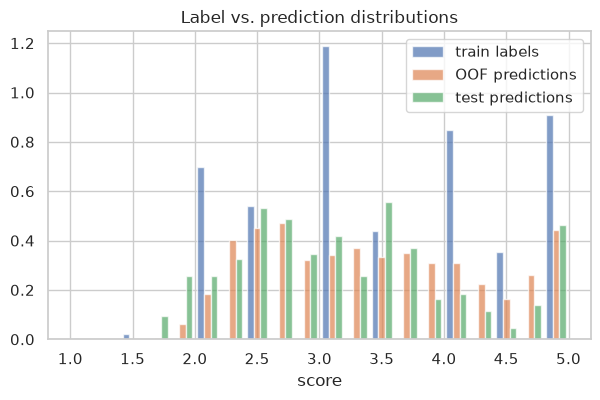

,count,mean,std,min,25%,50%,75%,max
label,216.0,3.214625,0.89258,1.602793,2.488988,3.10676,3.708314,5.0


In [20]:
res_final = T.run(folds=5, repeats=3, pseudo=res["test_pred"]["blend"].values, pseudo_weight=0.5)
print("change vs. first pass (RMS):", round(T.rmse(res["test_pred"]["blend"], res_final["test_pred"]["blend"]), 4))

# topic-aware blend: weights and calibration chosen on topic-grouped OOF predictions
final_pred, topic_w = T.topic_blend(res_final, 5, 3)
print("blend weights, plain CV:   ", {k: round(v, 3) for k, v in res_final["weights"].items() if v > 0})
print("blend weights, topic CV:   ", {k: round(v, 3) for k, v in topic_w.items() if v > 0})
sub = pd.DataFrame({"filename": res_final["test_pred"].index, "label": final_pred})
assert len(sub) == len(test) and set(sub.filename) == set(test.filename) and sub.label.between(0, 5).all()
sub.to_csv(ROOT / "submission.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist([y, oof["blend"], sub.label], bins=20, density=True, label=["train labels", "OOF predictions", "test predictions"], alpha=.7)
ax.set(title="Label vs. prediction distributions", xlabel="score"); ax.legend()
plt.show()
sub.describe().T

## Summary

- **Final model:** importance-weighted, pseudo-labelled, topic-aware NNLS blend of a fine-tuned DeBERTa-v3-base on Whisper transcripts (10 seeds x 5 folds), Ridge models on frozen WavLM speech embeddings (WavLM-large layer 21, WavLM-base layer 9) and a LightGBM on interpretable fluency / grammar / audio features; linearly calibrated and clipped to [0, 5].
- **Results:** training RMSE ≈ 0.23, cross-validated RMSE ≈ 0.51 (test-weighted ≈ 0.49, Pearson ≈ 0.87), public leaderboard RMSE 0.3173.
- **What mattered most:** (1) fine-tuning a text model on the transcripts instead of only using frozen text features; (2) adding a frozen self-supervised speech model, which on its own predicts the grammar score as well as the text model and is complementary to it; (3) checking the data: the zero-score clips were noise, and the test clips are shorter, faster and on different prompts, which importance weighting, pseudo-labelling and a blend chosen on held-out prompts correct for.
- **Limitations:** ~730 labels; transcripts can hide errors the raters heard; speech features may partly reflect accent or delivery rather than grammar, which would matter for fairness in a real assessment.
- **Next steps:** a validation split that mimics the test conditions (short crops, held-out prompts) to make audio-model selection reliable, a second literal (CTC) transcript to catch errors Whisper smooths over (a second Whisper transcript was too similar to help), and per-group error analysis if speaker metadata were available.